In [1]:
# ==============================================================================
# In[1] : Imports and Global Settings
# ==============================================================================
import sys
import os
import numpy as np
import pandas as pd
import pickle
import gc
from tqdm import tqdm
from collections import defaultdict
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# --- Add project root to path to import custom modules ---
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
    src_path = os.path.join(project_root, 'src')
    if src_path not in sys.path:
        sys.path.append(src_path)

    from preprocessing import load_dataset, preprocess_image
    from models import build_cnn, CustomActivation
    print("✅ Custom modules imported successfully.")
except ImportError as e:
    print(f"❌ Error importing custom modules: {e}")
    sys.exit(1)

# Set seaborn style for prettier plots
sns.set_theme(style="whitegrid")



2025-07-05 01:13:20.543622: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-05 01:13:20.692591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751703200.747585    1056 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751703200.763356    1056 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751703200.876100    1056 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ Custom modules imported successfully.


In [2]:

# ==============================================================================
# In[2] : Part 1 - The Training Function
# ==============================================================================

def run_training_pipeline(loss_type: str, params: dict):
    """
    Runs the complete training pipeline for a given loss type using a fixed data split.
    Saves models and returns performance data.
    """
    print(f"\n{'='*40}\n🔬 STARTING TRAINING: {loss_type.upper()} MODELS\n{'='*40}")
    
    base_output_dir = params['output_paths'][loss_type]
    model_save_dir = os.path.join(base_output_dir, 'models')
    os.makedirs(model_save_dir, exist_ok=True)
    
    print(f"📦 Models will be saved to: {model_save_dir}")
    
    df, images_data_dict, labels = load_dataset(params['data_folder'], target_size=params['base_target_size'])
    
    # --- Fixed Data Split Logic ---
    train_indices, test_indices = [], []
    for i, row in df.iterrows():
        if '_0.png' in row['img_id']:
            test_indices.append(i)
        else:
            train_indices.append(i)

    # Use the full path from the keys of images_data_dict to get the image arrays
    all_image_paths = list(images_data_dict.keys())
    X = np.array([images_data_dict[p] for p in all_image_paths])
    Y = labels

    X_train, Y_train = X[train_indices], Y[train_indices]
    X_test, Y_test = X[test_indices], Y[test_indices]
    
    print(f"✅ Data split determined: {len(X_train)} training samples, {len(X_test)} test samples.")
    
    training_history = defaultdict(list)

    for iteration in range(params['num_iterations']):
        print(f"\n--- Starting Training Iteration {iteration + 1}/{params['num_iterations']} ---")
        param_combinations = [(th, s_p, s_n) for th in params['threshold_list'] for s_p in params['positive_slope_list'] for s_n in params['negative_slope_list']]
        
        for th, s_p, s_n in tqdm(param_combinations, desc=f'Training Models (Iter {iteration+1})'):
            key = (s_p, s_n, params['noise_level'], th)
            tf.keras.backend.clear_session()

            is_categorical = (loss_type == 'categorical')
            model = build_cnn(
                input_shape=params['model_input_shape'],
                slope_positive=s_p, slope_negative=s_n, threshold=th,
                noise_level=params['noise_level'], num_classes=labels.shape[1],
                categorical=is_categorical
            )
            
            history = model.fit(
                X_train, Y_train,
                validation_data=(X_test, Y_test),
                epochs=params['epochs'], batch_size=64, verbose=0
            )

            training_history[key].append(history.history)
            
            model_filename = f"model_iter_{iteration}_sp_{s_p}_sn_{s_n}_th_{th}.keras"
            model.save(os.path.join(model_save_dir, model_filename))
            del model, history
            gc.collect()

    print(f"\n🎉 --- All training for {loss_type.upper()} completed. --- 🎉")
    return training_history

# ==============================================================================
# In[3] : Part 2 - The Analysis and Visualization Function
# ==============================================================================

def analyze_and_plot_results(all_training_history, analysis_params):
    """
    Performs all analysis and generates all plots with enhanced visualization.
    
    NEW FEATURES:
    1. Plots separate, large figures for Training and Test accuracy.
    2. Uses a specific color scheme: color for slope, style for loss type.
    3. Continues to perform Logit/Entropy analysis on the training set.
    """
    print(f"\n{'='*40}\n📊 STARTING ENHANCED ANALYSIS & VISUALIZATION\n{'='*40}")
    custom_objects = {'CustomActivation': CustomActivation}

    # ==========================================================================
    # 1. 新功能：训练/测试准确率可视化 (增强版)
    # ==========================================================================
    print("--- Plotting 1/4 & 2/4: Enhanced Training & Test Accuracy Curves ---")
    
    # --- a) 数据准备 ---
    acc_data_list = []
    for loss_type, history_dict in all_training_history.items():
        for key, iteration_histories in history_dict.items():
            slope_val = key[0]
            for i, history in enumerate(iteration_histories):
                # 安全地获取数据，防止因提前停止等原因导致长度不一
                max_epochs = len(history.get('accuracy', []))
                for epoch in range(max_epochs):
                    acc_data_list.append({
                        'Loss Type': loss_type, 
                        'Slope': slope_val, 
                        'iteration': i, 
                        'Epoch': epoch + 1,
                        'Accuracy': history['accuracy'][epoch], 
                        'Set': 'Training'
                    })
                    acc_data_list.append({
                        'Loss Type': loss_type, 
                        'Slope': slope_val, 
                        'iteration': i, 
                        'Epoch': epoch + 1,
                        'Accuracy': history['val_accuracy'][epoch], 
                        'Set': 'Test'
                    })
    df_acc = pd.DataFrame(acc_data_list)
    
    # --- b) 定义颜色和样式 ---
    # 定义一个调色板，为每个slope分配一个清晰的颜色
    palette = {0.005: "C0", 0.05: "C2", 0.5: "C3"} # Blue, Green, Red

    # --- c) 绘制第一张独立的图：训练准确率 ---
    plt.figure(figsize=(18, 10)) # ✅ 放大图片尺寸
    sns.lineplot(data=df_acc[df_acc['Set'] == 'Training'], 
                 x='Epoch', y='Accuracy', 
                 hue='Slope', style='Loss Type', # ✅ 颜色区分slope, 样式区分loss_type
                 palette=palette, errorbar='sd')
    
    plt.title('Training Accuracy (Mean & SD across Iterations)', fontsize=20, pad=20)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.ylim(0, 1.05) # 固定Y轴范围
    plt.legend(title='Parameters', loc='best', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(analysis_params['base_analysis_dir'], 'A_training_accuracy_curves.png'))
    plt.show()

    # # --- d) 绘制第二张独立的图：测试准确率 ---
    # plt.figure(figsize=(18, 10)) # ✅ 放大图片尺寸
    # sns.lineplot(data=df_acc[df_acc['Set'] == 'Test'], 
    #              x='Epoch', y='Accuracy', 
    #              hue='Slope', style='Loss Type', # ✅ 颜色区分slope, 样式区分loss_type
    #              palette=palette, errorbar='sd')
                 
    # plt.title('Test Accuracy (Mean & SD across Iterations)', fontsize=20, pad=20)
    # plt.xlabel('Epoch', fontsize=14)
    # plt.ylabel('Accuracy', fontsize=14)
    # plt.ylim(0, 1.05) # 固定Y轴范围
    # plt.legend(title='Parameters', loc='best', fontsize=12)
    # plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # plt.tight_layout()
    # plt.savefig(os.path.join(analysis_params['base_analysis_dir'], 'B_test_accuracy_curves.png'))
    # plt.show()

    # ==========================================================================
    # 2. Logits 和 Entropy 分析
    # ==========================================================================
    # (此部分为您的代码，现在可以正确运行)
    df, _, labels = load_dataset(analysis_params['data_folder'], target_size=analysis_params['base_target_size'])
    all_indices, test_indices = np.arange(len(df)), np.arange(0, len(df), 5)
    train_indices = np.setdiff1d(all_indices, test_indices)
    
    x_train_list, y_train_list = [], []
    for i in train_indices:
        row = df.iloc[i]
        person_name = row.iloc[1:][row.iloc[1:] == 1].index[0]
        full_path = os.path.join(analysis_params['data_folder'], person_name, row['img_id'])
        x_train_list.append(preprocess_image(full_path, analysis_params['base_target_size'][0]))
    X_train_analysis = np.array(x_train_list)
    Y_train_analysis = labels[train_indices]

    all_analysis_results = defaultdict(list)
    
    for loss_type in ['categorical', 'binary']:
        print(f"\n--- Analyzing models for: {loss_type.upper()} ---")
        base_dir = analysis_params['output_paths'][loss_type]
        model_dir = os.path.join(base_dir, 'models')
        
        # A. SINGLE IMAGE CASE STUDY
        img_array = preprocess_image(analysis_params['single_image_path'], analysis_params['base_target_size'][0])
        img_batch = np.expand_dims(img_array, axis=0)
        for s_p in tqdm(analysis_params['positive_slope_list'], desc=f"Case Study ({loss_type})"):
            model_path = os.path.join(model_dir, f"model_iter_{analysis_params['analysis_iteration']}_sp_{s_p}_sn_0_th_0.keras")
            if not os.path.exists(model_path):
                print(f"\n[Warning] Case study model not found, skipping. Path: {model_path}")
                continue
            # 现在 custom_objects 已定义，此行可以成功执行
            model = tf.keras.models.load_model(model_path, custom_objects=custom_objects, compile=False)
            intermediate_model = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-2].output)
            logits, softmax_probs = intermediate_model.predict(img_batch, verbose=0)[0], model.predict(img_batch, verbose=0)[0]
            sorted_indices = np.argsort(logits)[::-1]
            runner_up_idx = sorted_indices[1] if sorted_indices[0] == analysis_params['juliana_index'] else sorted_indices[0]
            all_analysis_results['case_study'].append({'loss_type': loss_type, 'slope': s_p, 'correct_logit': logits[analysis_params['juliana_index']], 'runner_up_logit': logits[runner_up_idx]})

        # B. TRAINING SET ANALYSIS
        val_set_results = []
        for s_p in tqdm(analysis_params['positive_slope_list'], desc=f"Training Set Analysis ({loss_type})"):
            model_path = os.path.join(model_dir, f"model_iter_{analysis_params['analysis_iteration']}_sp_{s_p}_sn_0_th_0.keras")
            if not os.path.exists(model_path):
                print(f"\n[Warning] Training set analysis model not found, skipping. Path: {model_path}")
                continue
            # 现在 custom_objects 已定义，此行可以成功执行
            model = tf.keras.models.load_model(model_path, custom_objects=custom_objects, compile=False)
            intermediate_model = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-2].output)
            logits_val, softmax_val = intermediate_model.predict(X_train_analysis, verbose=0), model.predict(X_train_analysis, verbose=0)
            correct_indices = np.argmax(Y_train_analysis, axis=1)
            for i in range(len(Y_train_analysis)):
                entropy = -np.sum(softmax_val[i] * np.log(softmax_val[i] + 1e-9))
                for j in range(logits_val.shape[1]):
                    val_set_results.append({'loss_type': loss_type, 'slope': s_p, 'logit_value': logits_val[i, j],
                                            'is_correct_class': 'Correct' if j == correct_indices[i] else 'Incorrect',
                                            'entropy': entropy})
        all_analysis_results['training_set_dist'].extend(val_set_results)
    
    # --- 4. Generate Analysis Plots ---
    print("\n--- Plotting 2/4: Single Image Case Study ---")
    df_case_study = pd.DataFrame(all_analysis_results['case_study'])
    if not df_case_study.empty:
        df_plot_case = df_case_study.melt(id_vars=['loss_type', 'slope'], value_vars=['correct_logit', 'runner_up_logit'], var_name='logit_type', value_name='logit_value')
        plt.figure(figsize=(15, 7))
        sns.barplot(data=df_plot_case, x='slope', y='logit_value', hue='loss_type', hue_order=['categorical', 'binary'], errorbar=None)
        plt.title('Case Study: Logit Comparison for "juliana_0.png"', fontsize=16)
        plt.savefig(os.path.join(analysis_params['base_analysis_dir'], 'case_study_comparison.png'))
        plt.show()
    else:
        print("\n[INFO] No data for Case Study plot. Skipping.")

    print("--- Plotting 3/4: Logit Distribution on Training Set ---")
    df_dist = pd.DataFrame(all_analysis_results['training_set_dist'])
    if not df_dist.empty:
        plt.figure(figsize=(18, 9))
        sns.violinplot(data=df_dist, x='slope', y='logit_value', hue='loss_type', split=True, inner='quart', hue_order=['categorical', 'binary'], palette='muted')
        plt.title('Logit Distribution on Training Set', fontsize=16)
        if not df_dist[df_dist['is_correct_class']=='Correct'].empty:
            plt.ylim(df_dist['logit_value'].min(), df_dist[df_dist['is_correct_class']=='Correct']['logit_value'].quantile(0.99))
        plt.savefig(os.path.join(analysis_params['base_analysis_dir'], 'logit_distribution_comparison.png'))
        plt.show()
    else:
        print("\n[INFO] No data for Case Study plot. Skipping.")

    print("--- Plotting 4/4: Prediction Confidence on Training Set ---")
    if not df_dist.empty:
        df_entropy = df_dist[['loss_type', 'slope', 'entropy']].drop_duplicates()
        plt.figure(figsize=(15, 7))
        sns.kdeplot(data=df_entropy, x='entropy', hue='loss_type', fill=True, hue_order=['categorical', 'binary'], common_norm=False)
        plt.title('Prediction Confidence (Entropy) on Training Set', fontsize=16)
        plt.xlabel('Entropy (Lower is More Confident)')
        plt.savefig(os.path.join(analysis_params['base_analysis_dir'], 'entropy_distribution_comparison.png'))
        plt.show()
    else:
        print("\n[INFO] No data for Case Study plot. Skipping.")

    print("\n🎉 --- Analysis and Visualization complete! --- 🎉")


🔬 STARTING TRAINING: CATEGORICAL MODELS
📦 Models will be saved to: ../res/EIB_bc/c/models
✅ Data split determined: 40 training samples, 10 test samples.

--- Starting Training Iteration 1/10 ---


Training Models (Iter 1):   0%|          | 0/3 [00:00<?, ?it/s]

➡️ Compiling model with loss function: categorical_crossentropy


Training Models (Iter 1):  33%|███▎      | 1/3 [01:07<02:15, 67.56s/it]

➡️ Compiling model with loss function: categorical_crossentropy


...

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10):  67%|██████▋   | 2/3 [02:56<01:30, 90.97s/it]

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10): 100%|██████████| 3/3 [04:09<00:00, 83.13s/it]



🎉 --- All training for BINARY completed. --- 🎉

📊 STARTING ENHANCED ANALYSIS & VISUALIZATION
--- Plotting 1/4 & 2/4: Enhanced Training & Test Accuracy Curves ---


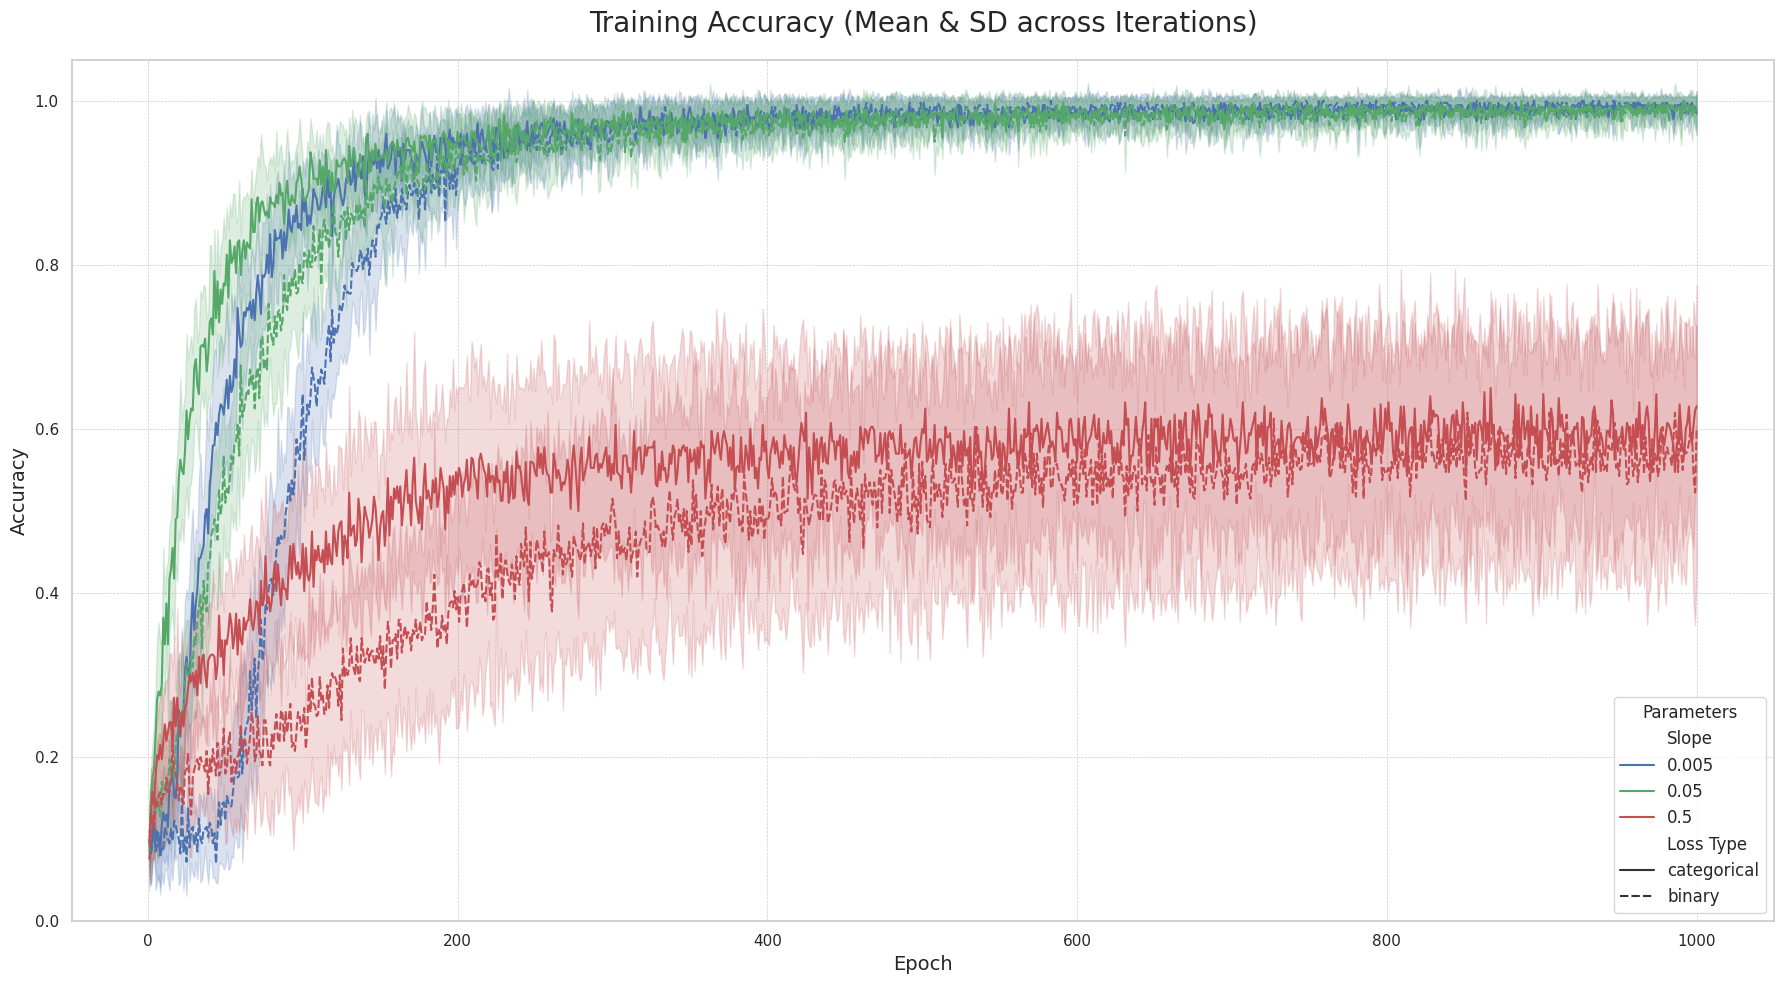


--- Analyzing models for: CATEGORICAL ---


Training Set Analysis (categorical): 100%|██████████| 3/3 [00:04<00:00,  1.66s/it]



--- Analyzing models for: BINARY ---


Training Set Analysis (binary): 100%|██████████| 3/3 [00:04<00:00,  1.65s/it]


--- Plotting 2/4: Single Image Case Study ---


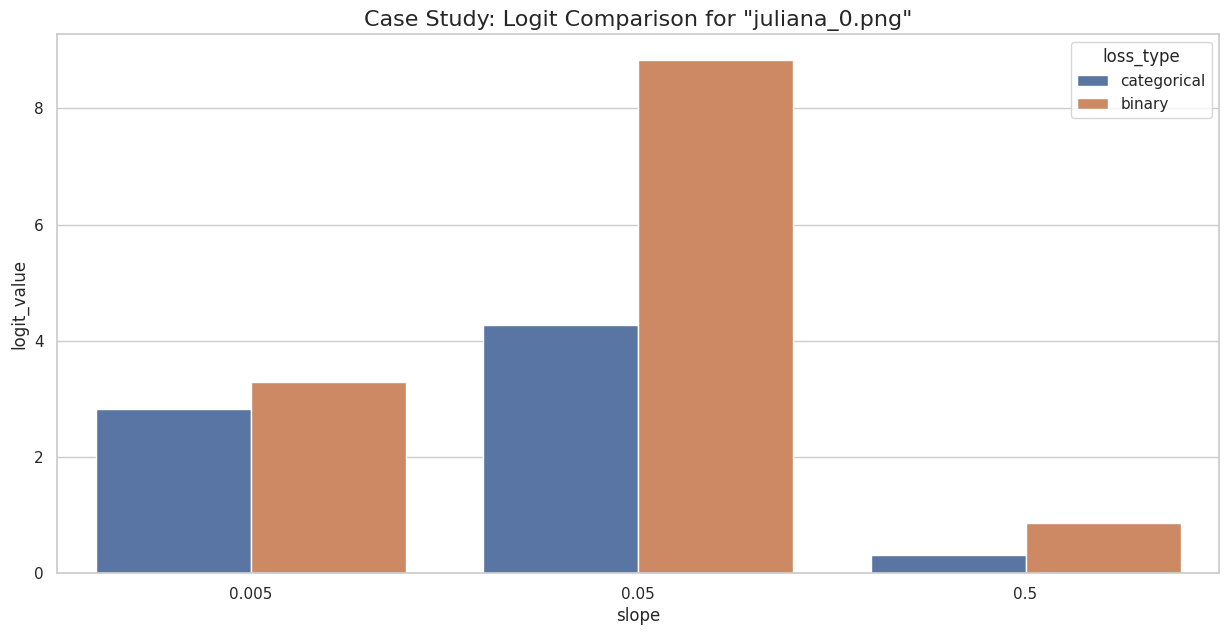

--- Plotting 3/4: Logit Distribution on Training Set ---


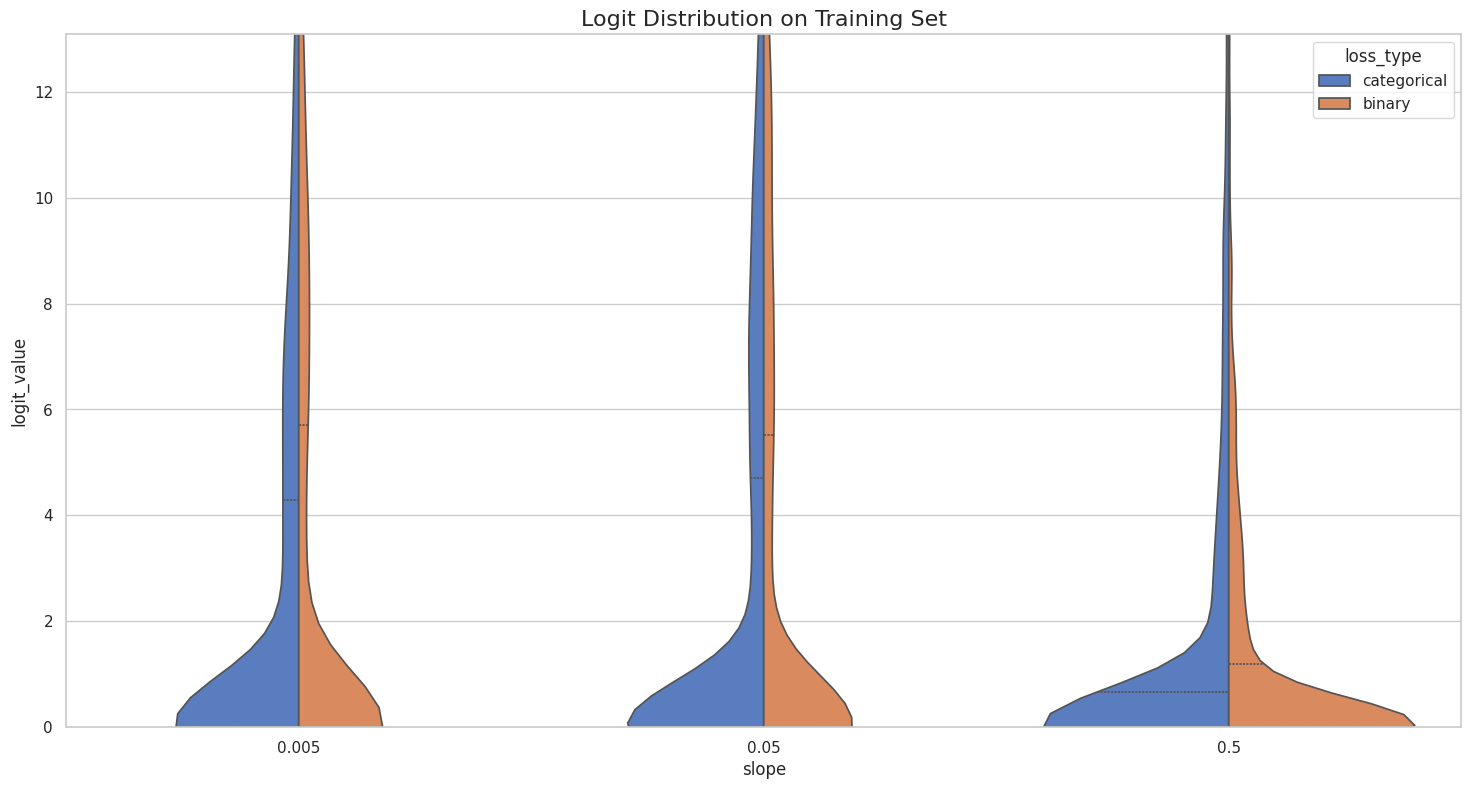

--- Plotting 4/4: Prediction Confidence on Training Set ---


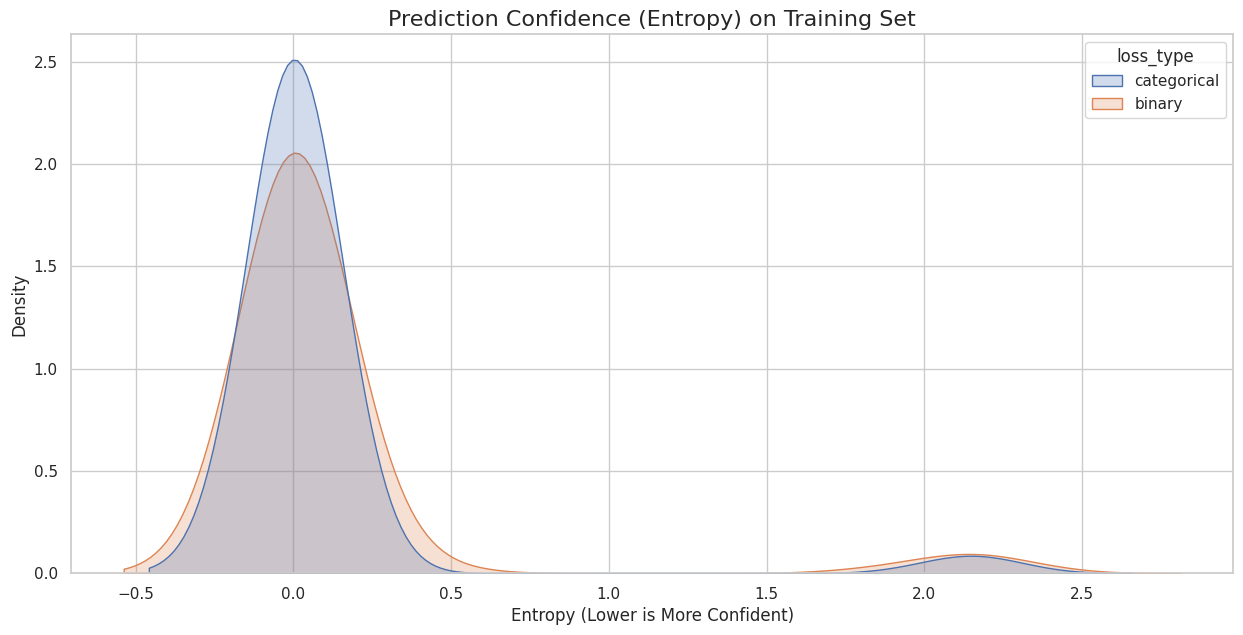


🎉 --- Analysis and Visualization complete! --- 🎉


✅✅✅ Entire pipeline completed successfully! ✅✅✅


In [19]:
BASE_RESIZE_TARGET = (128, 128)
FINAL_MODEL_INPUT_SHAPE = (130, 130, 3)
BASE_ANALYSIS_DIR = '../res/EIB_bc/'
os.makedirs(BASE_ANALYSIS_DIR, exist_ok=True)

training_params = {
    'positive_slope_list': [0.005, 0.05, 0.5], 
    'negative_slope_list': [0],
    'noise_level': 0, 
    'threshold_list': [0], 
    'epochs': 1000,
    'num_iterations': 10, 
    'data_folder': '../data/training_data',
    'base_target_size': BASE_RESIZE_TARGET, 'model_input_shape': FINAL_MODEL_INPUT_SHAPE,
    'output_paths': {
        'categorical': os.path.join(BASE_ANALYSIS_DIR, 'c/'),
        'binary': os.path.join(BASE_ANALYSIS_DIR, 'b/')
    }
}

all_training_history = {}
for loss_type in ['categorical', 'binary']:
    history = run_training_pipeline(loss_type, params=training_params)
    all_training_history[loss_type] = history

analysis_params = {
    'base_analysis_dir': BASE_ANALYSIS_DIR,
    'output_paths': training_params['output_paths'],
    'positive_slope_list': training_params['positive_slope_list'],
    'analysis_iteration': 0,
    'single_image_path': os.path.join(training_params['data_folder'], 'juliana/juliana_0.png'),
    'juliana_index': 0,
    'data_folder': training_params['data_folder'],
    'base_target_size': BASE_RESIZE_TARGET
}

analyze_and_plot_results(all_training_history, analysis_params)

print("\n\n✅✅✅ Entire pipeline completed successfully! ✅✅✅")



🔬 STARTING TRAINING: CATEGORICAL MODELS
📦 Models will be saved to: ../res/EIB_bc_250/c/models
✅ Data split determined: 40 training samples, 10 test samples.

--- Starting Training Iteration 1/10 ---


Training Models (Iter 1):   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1751703322.560012    1056 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9502 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


➡️ Compiling model with loss function: categorical_crossentropy


I0000 00:00:1751703324.566044    1683 service.cc:152] XLA service 0x7a80c4018dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751703324.566067    1683 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2025-07-05 01:15:24.613289: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751703324.848970    1683 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1751703328.937108    1683 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Training Models (Iter 1):  33%|███▎      | 1/3 [00:21<00:43, 21.90s/it]

➡️ Compiling model with loss function: categorical_crossentropy


...

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10):  67%|██████▋   | 2/3 [00:43<00:21, 21.55s/it]

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10): 100%|██████████| 3/3 [01:07<00:00, 22.45s/it]



🎉 --- All training for BINARY completed. --- 🎉

📊 STARTING ENHANCED ANALYSIS & VISUALIZATION
--- Plotting 1/4 & 2/4: Enhanced Training & Test Accuracy Curves ---


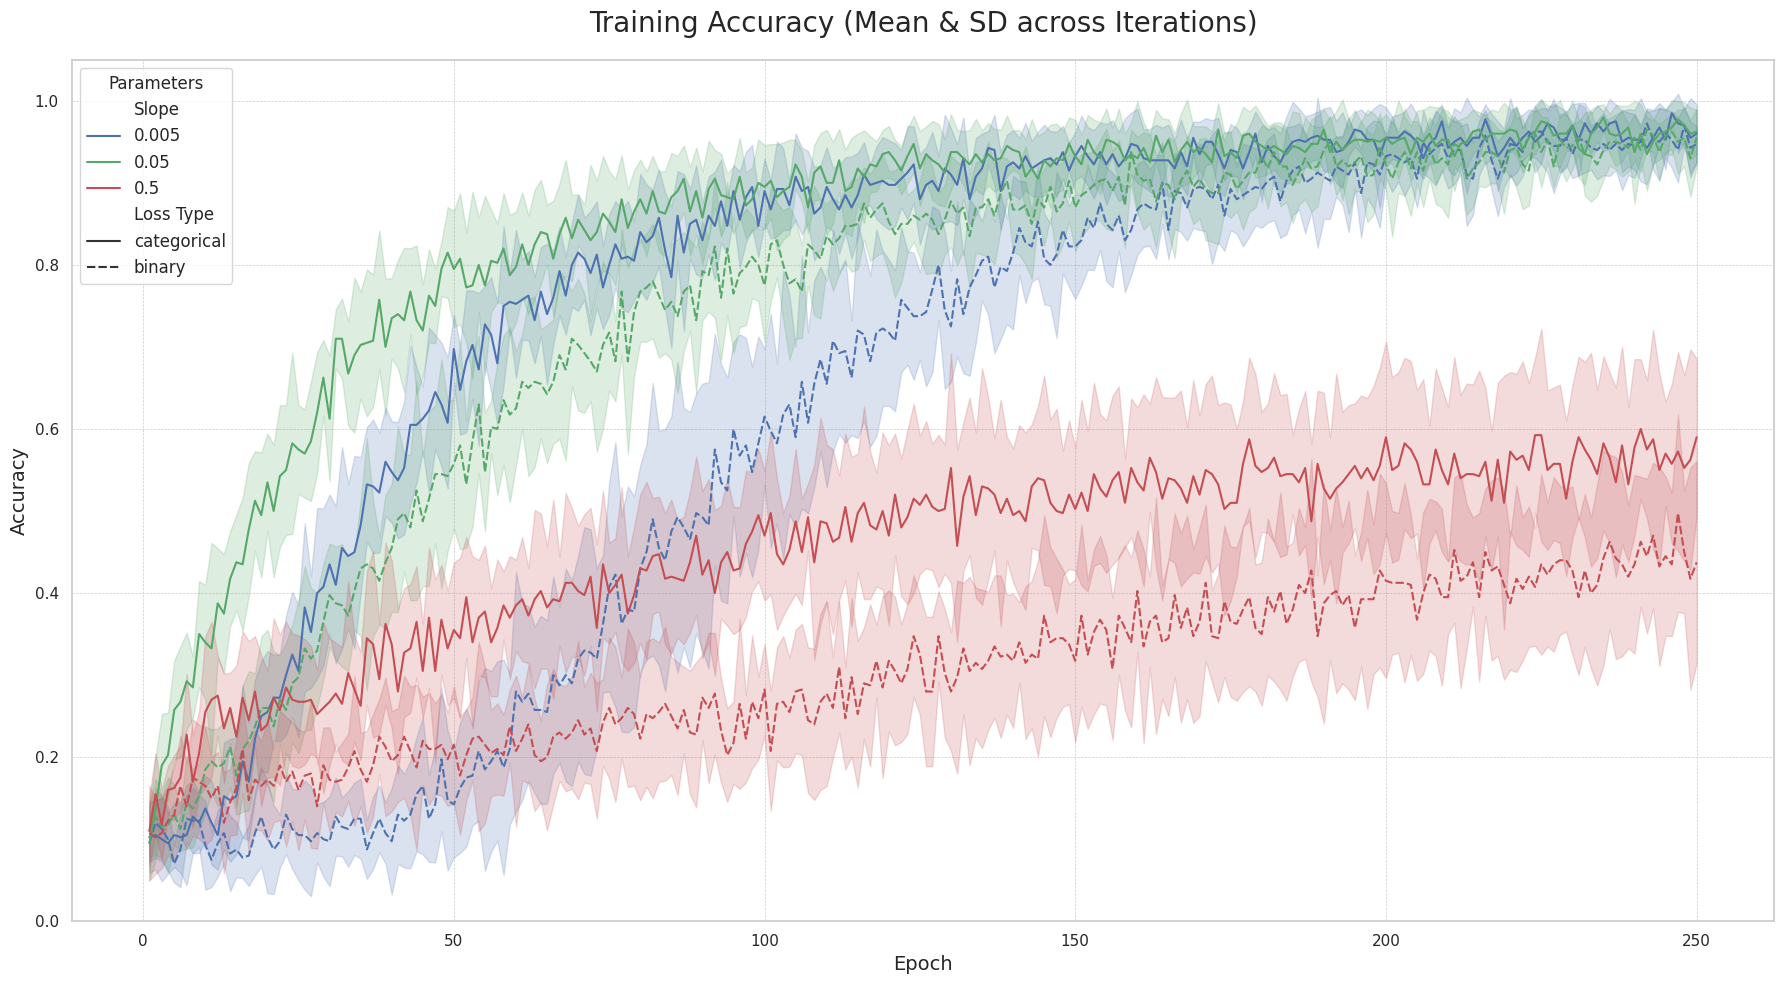


--- Analyzing models for: CATEGORICAL ---


Case Study (categorical):  67%|██████▋   | 2/3 [00:02<00:01,  1.05s/it]

Training Set Analysis (categorical):   0%|          | 0/3 [00:00<?, ?it/s]2025-07-05 01:37:08.528131: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_147', 12 bytes spill stores, 12 bytes spill loads

2025-07-05 01:37:08.572747: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_147', 4 bytes spill stores, 4 bytes spill loads

Training Set Analysis (categorical): 100%|██████████| 3/3 [00:04<00:00,  1.42s/it]



--- Analyzing models for: BINARY ---


Training Set Analysis (binary): 100%|██████████| 3/3 [00:05<00:00,  1.69s/it]


--- Plotting 2/4: Single Image Case Study ---


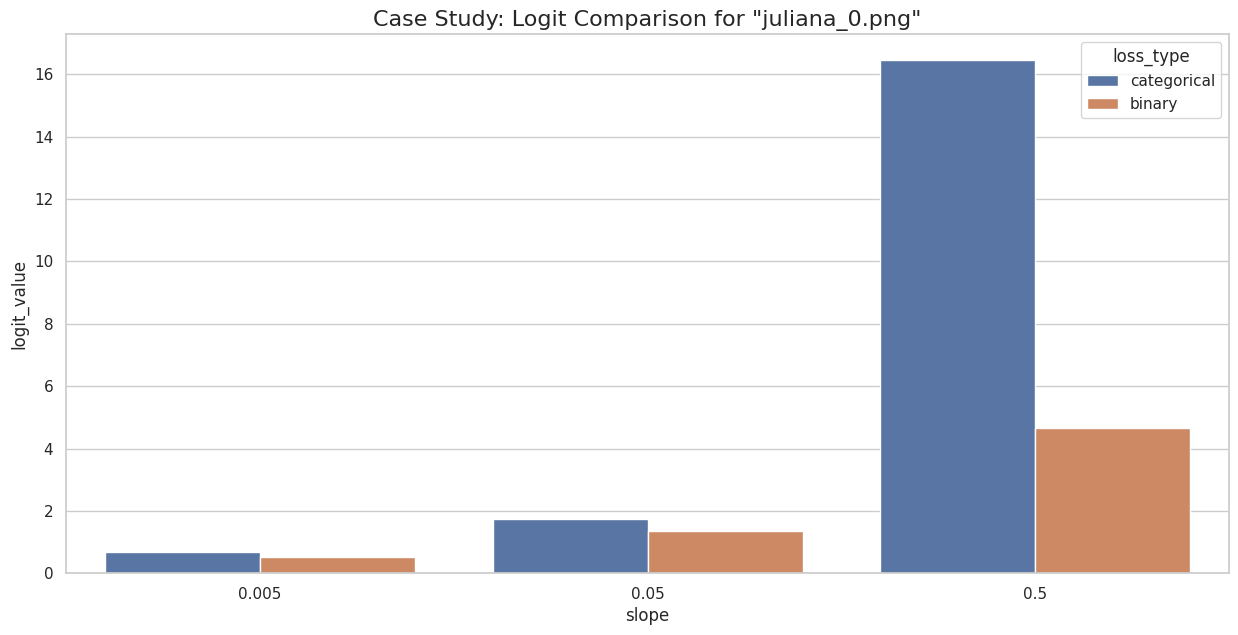

--- Plotting 3/4: Logit Distribution on Training Set ---


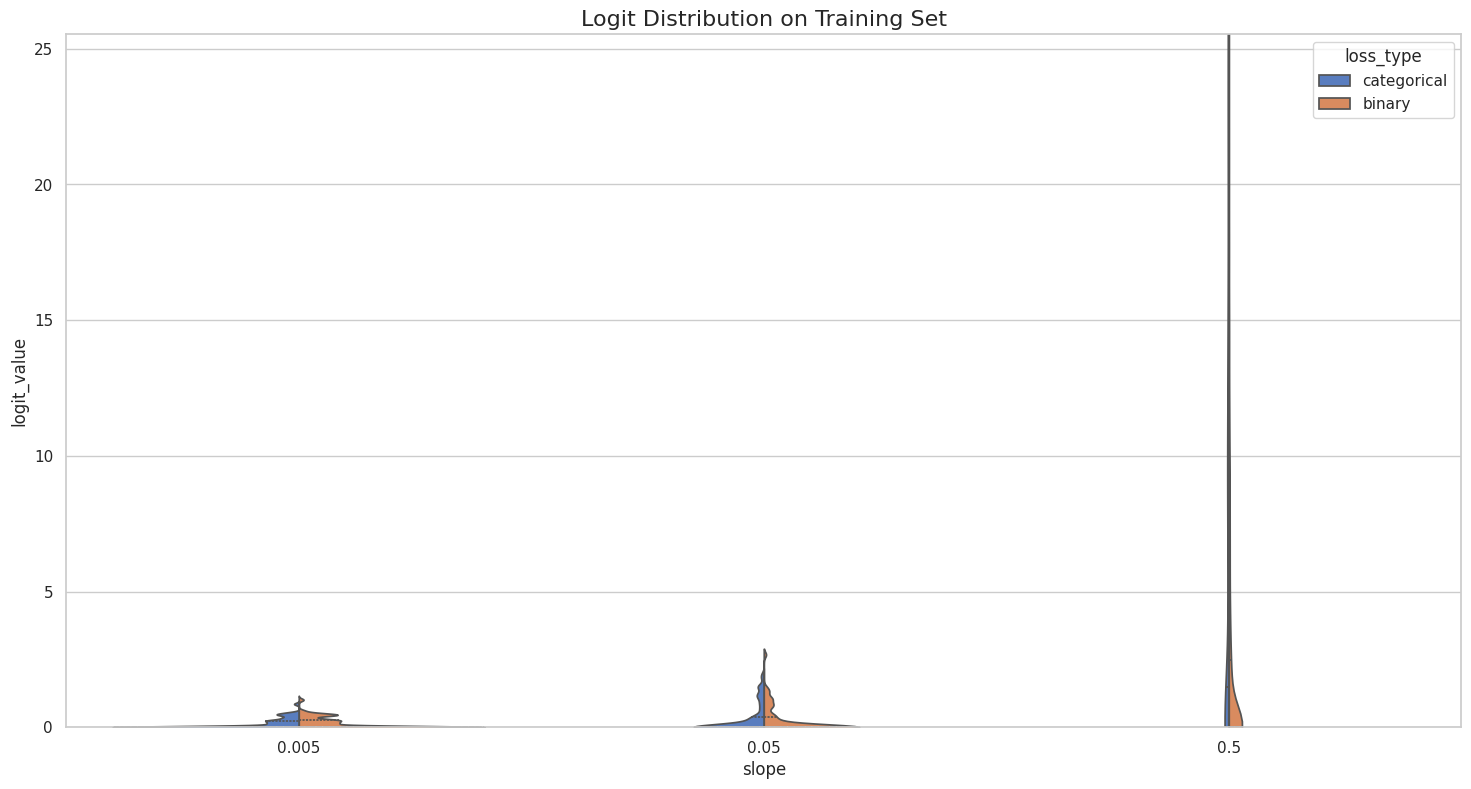

--- Plotting 4/4: Prediction Confidence on Training Set ---


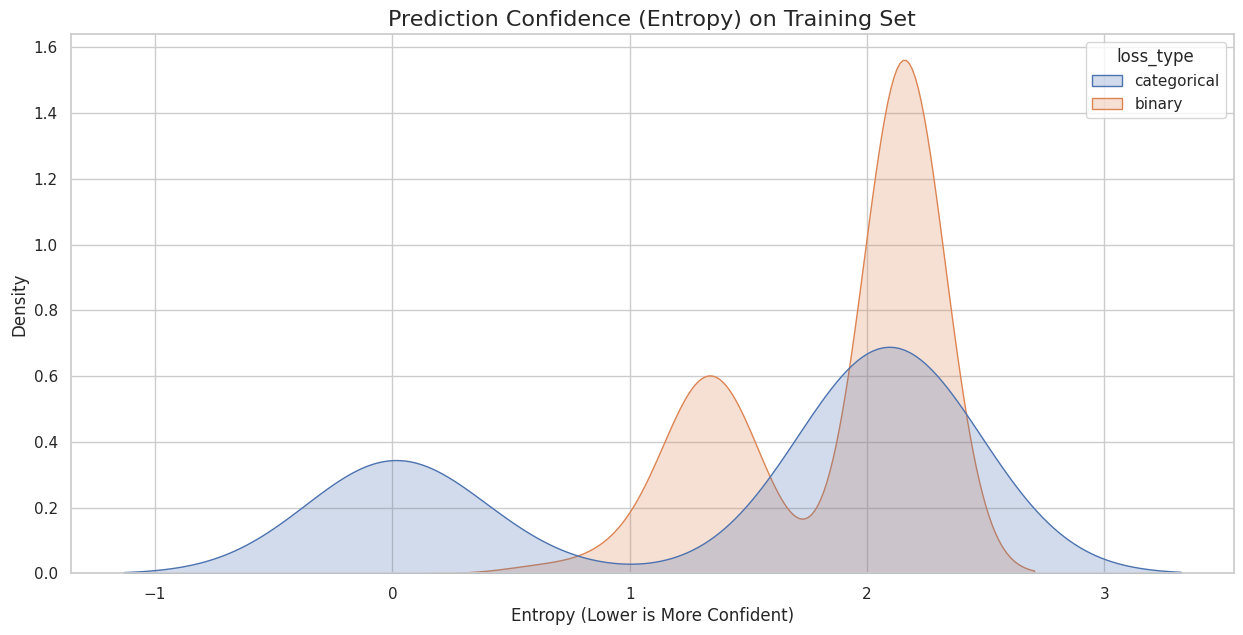


🎉 --- Analysis and Visualization complete! --- 🎉


✅✅✅ Entire pipeline completed successfully! ✅✅✅


In [3]:
BASE_RESIZE_TARGET = (128, 128)
FINAL_MODEL_INPUT_SHAPE = (130, 130, 3)
BASE_ANALYSIS_DIR = '../res/EIB_bc_250/'
os.makedirs(BASE_ANALYSIS_DIR, exist_ok=True)

training_params = {
    'positive_slope_list': [0.005, 0.05, 0.5], 
    'negative_slope_list': [0],
    'noise_level': 0, 
    'threshold_list': [0], 
    'epochs': 250,
    'num_iterations': 10, 
    'data_folder': '../data/training_data',
    'base_target_size': BASE_RESIZE_TARGET, 'model_input_shape': FINAL_MODEL_INPUT_SHAPE,
    'output_paths': {
        'categorical': os.path.join(BASE_ANALYSIS_DIR, 'c/'),
        'binary': os.path.join(BASE_ANALYSIS_DIR, 'b/')
    }
}

all_training_history = {}
for loss_type in ['categorical', 'binary']:
    history = run_training_pipeline(loss_type, params=training_params)
    all_training_history[loss_type] = history

analysis_params = {
    'base_analysis_dir': BASE_ANALYSIS_DIR,
    'output_paths': training_params['output_paths'],
    'positive_slope_list': training_params['positive_slope_list'],
    'analysis_iteration': 0,
    'single_image_path': os.path.join(training_params['data_folder'], 'juliana/juliana_0.png'),
    'juliana_index': 0,
    'data_folder': training_params['data_folder'],
    'base_target_size': BASE_RESIZE_TARGET
}

analyze_and_plot_results(all_training_history, analysis_params)

print("\n\n✅✅✅ Entire pipeline completed successfully! ✅✅✅")



🔬 STARTING TRAINING: CATEGORICAL MODELS
📦 Models will be saved to: ../res/EIB_bc_500/c/models
✅ Data split determined: 40 training samples, 10 test samples.

--- Starting Training Iteration 1/10 ---


Training Models (Iter 1):   0%|          | 0/3 [00:00<?, ?it/s]

➡️ Compiling model with loss function: categorical_crossentropy


Training Models (Iter 1):  33%|███▎      | 1/3 [00:39<01:19, 39.76s/it]

➡️ Compiling model with loss function: categorical_crossentropy


...

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10):  67%|██████▋   | 2/3 [01:22<00:41, 41.32s/it]

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10): 100%|██████████| 3/3 [02:01<00:00, 40.54s/it]



🎉 --- All training for BINARY completed. --- 🎉

📊 STARTING ENHANCED ANALYSIS & VISUALIZATION
--- Plotting 1/4 & 2/4: Enhanced Training & Test Accuracy Curves ---


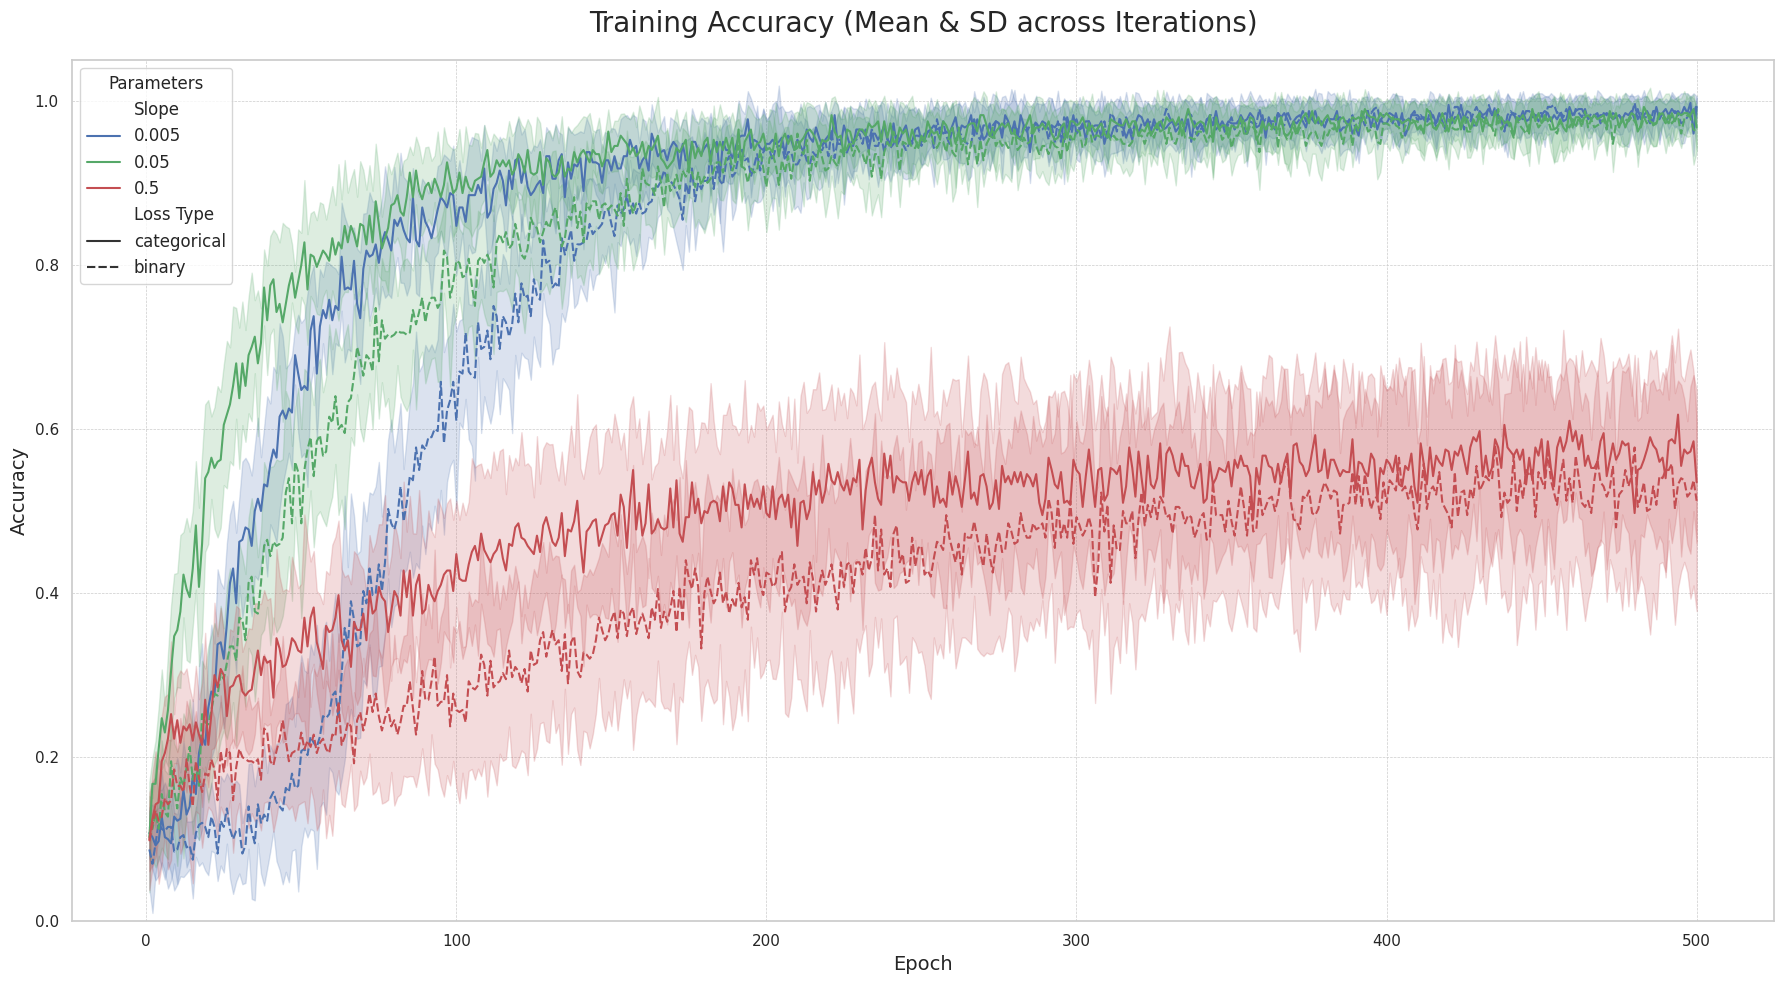


--- Analyzing models for: CATEGORICAL ---


Training Set Analysis (categorical): 100%|██████████| 3/3 [00:05<00:00,  1.75s/it]



--- Analyzing models for: BINARY ---


Training Set Analysis (binary): 100%|██████████| 3/3 [00:05<00:00,  1.73s/it]


--- Plotting 2/4: Single Image Case Study ---


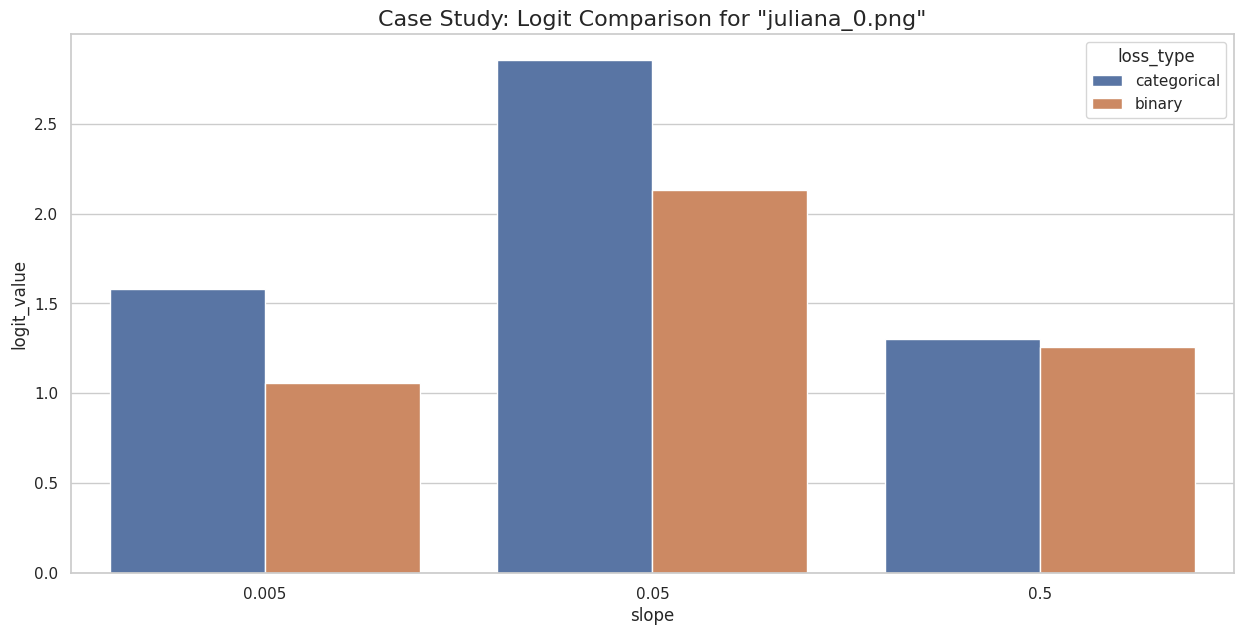

--- Plotting 3/4: Logit Distribution on Training Set ---


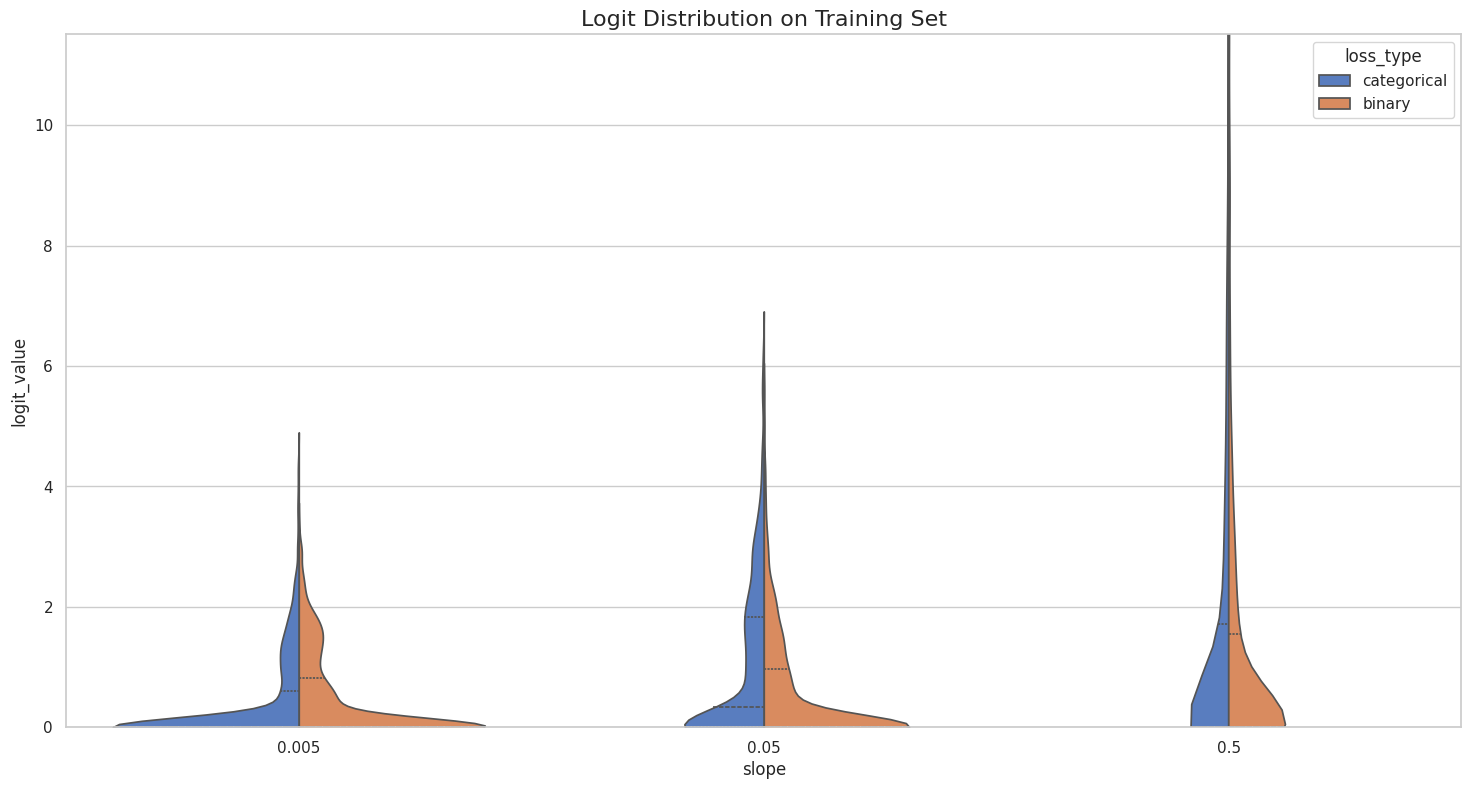

--- Plotting 4/4: Prediction Confidence on Training Set ---


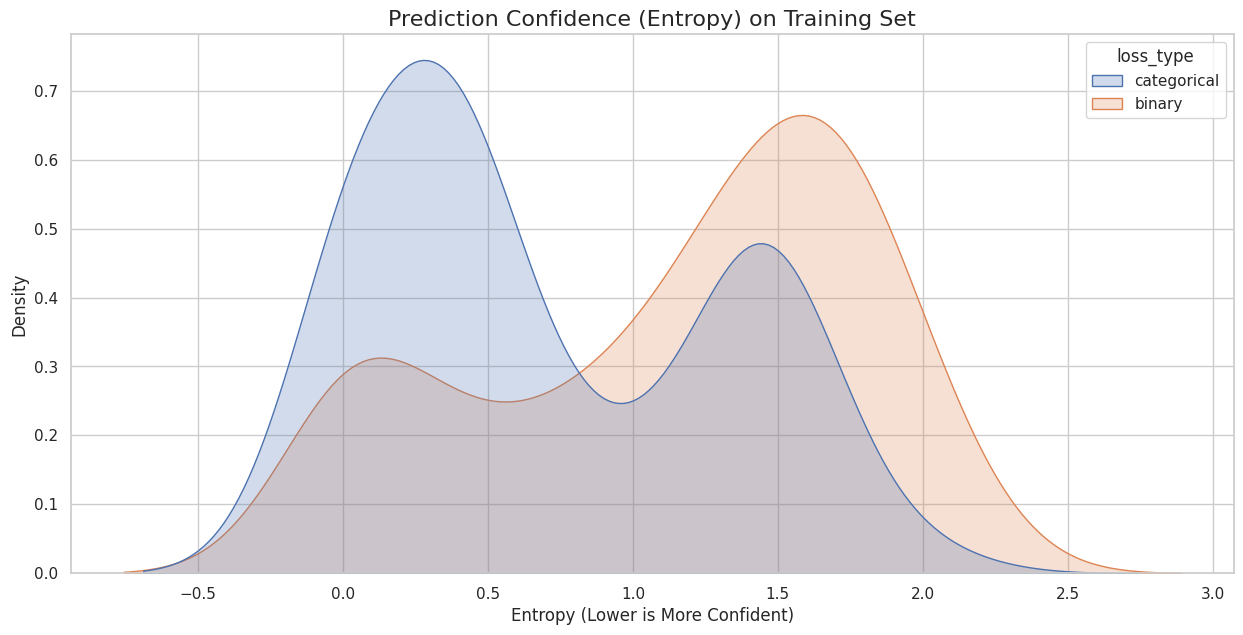


🎉 --- Analysis and Visualization complete! --- 🎉


✅✅✅ Entire pipeline completed successfully! ✅✅✅


In [4]:
BASE_RESIZE_TARGET = (128, 128)
FINAL_MODEL_INPUT_SHAPE = (130, 130, 3)
BASE_ANALYSIS_DIR = '../res/EIB_bc_500/'
os.makedirs(BASE_ANALYSIS_DIR, exist_ok=True)

training_params = {
    'positive_slope_list': [0.005, 0.05, 0.5], 
    'negative_slope_list': [0],
    'noise_level': 0, 
    'threshold_list': [0], 
    'epochs': 500,
    'num_iterations': 10, 
    'data_folder': '../data/training_data',
    'base_target_size': BASE_RESIZE_TARGET, 'model_input_shape': FINAL_MODEL_INPUT_SHAPE,
    'output_paths': {
        'categorical': os.path.join(BASE_ANALYSIS_DIR, 'c/'),
        'binary': os.path.join(BASE_ANALYSIS_DIR, 'b/')
    }
}

all_training_history = {}
for loss_type in ['categorical', 'binary']:
    history = run_training_pipeline(loss_type, params=training_params)
    all_training_history[loss_type] = history

analysis_params = {
    'base_analysis_dir': BASE_ANALYSIS_DIR,
    'output_paths': training_params['output_paths'],
    'positive_slope_list': training_params['positive_slope_list'],
    'analysis_iteration': 0,
    'single_image_path': os.path.join(training_params['data_folder'], 'juliana/juliana_0.png'),
    'juliana_index': 0,
    'data_folder': training_params['data_folder'],
    'base_target_size': BASE_RESIZE_TARGET
}

analyze_and_plot_results(all_training_history, analysis_params)

print("\n\n✅✅✅ Entire pipeline completed successfully! ✅✅✅")



🔬 STARTING TRAINING: CATEGORICAL MODELS
📦 Models will be saved to: ../res/EIB_bc_750/c/models
✅ Data split determined: 40 training samples, 10 test samples.

--- Starting Training Iteration 1/10 ---


Training Models (Iter 1):   0%|          | 0/3 [00:00<?, ?it/s]

➡️ Compiling model with loss function: categorical_crossentropy


Training Models (Iter 1):  33%|███▎      | 1/3 [00:58<01:57, 58.57s/it]

➡️ Compiling model with loss function: categorical_crossentropy


...

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10):  67%|██████▋   | 2/3 [01:59<00:59, 59.60s/it]

➡️ Compiling model with loss function: binary_crossentropy


Training Models (Iter 10): 100%|██████████| 3/3 [02:58<00:00, 59.64s/it]



🎉 --- All training for BINARY completed. --- 🎉

📊 STARTING ENHANCED ANALYSIS & VISUALIZATION
--- Plotting 1/4 & 2/4: Enhanced Training & Test Accuracy Curves ---


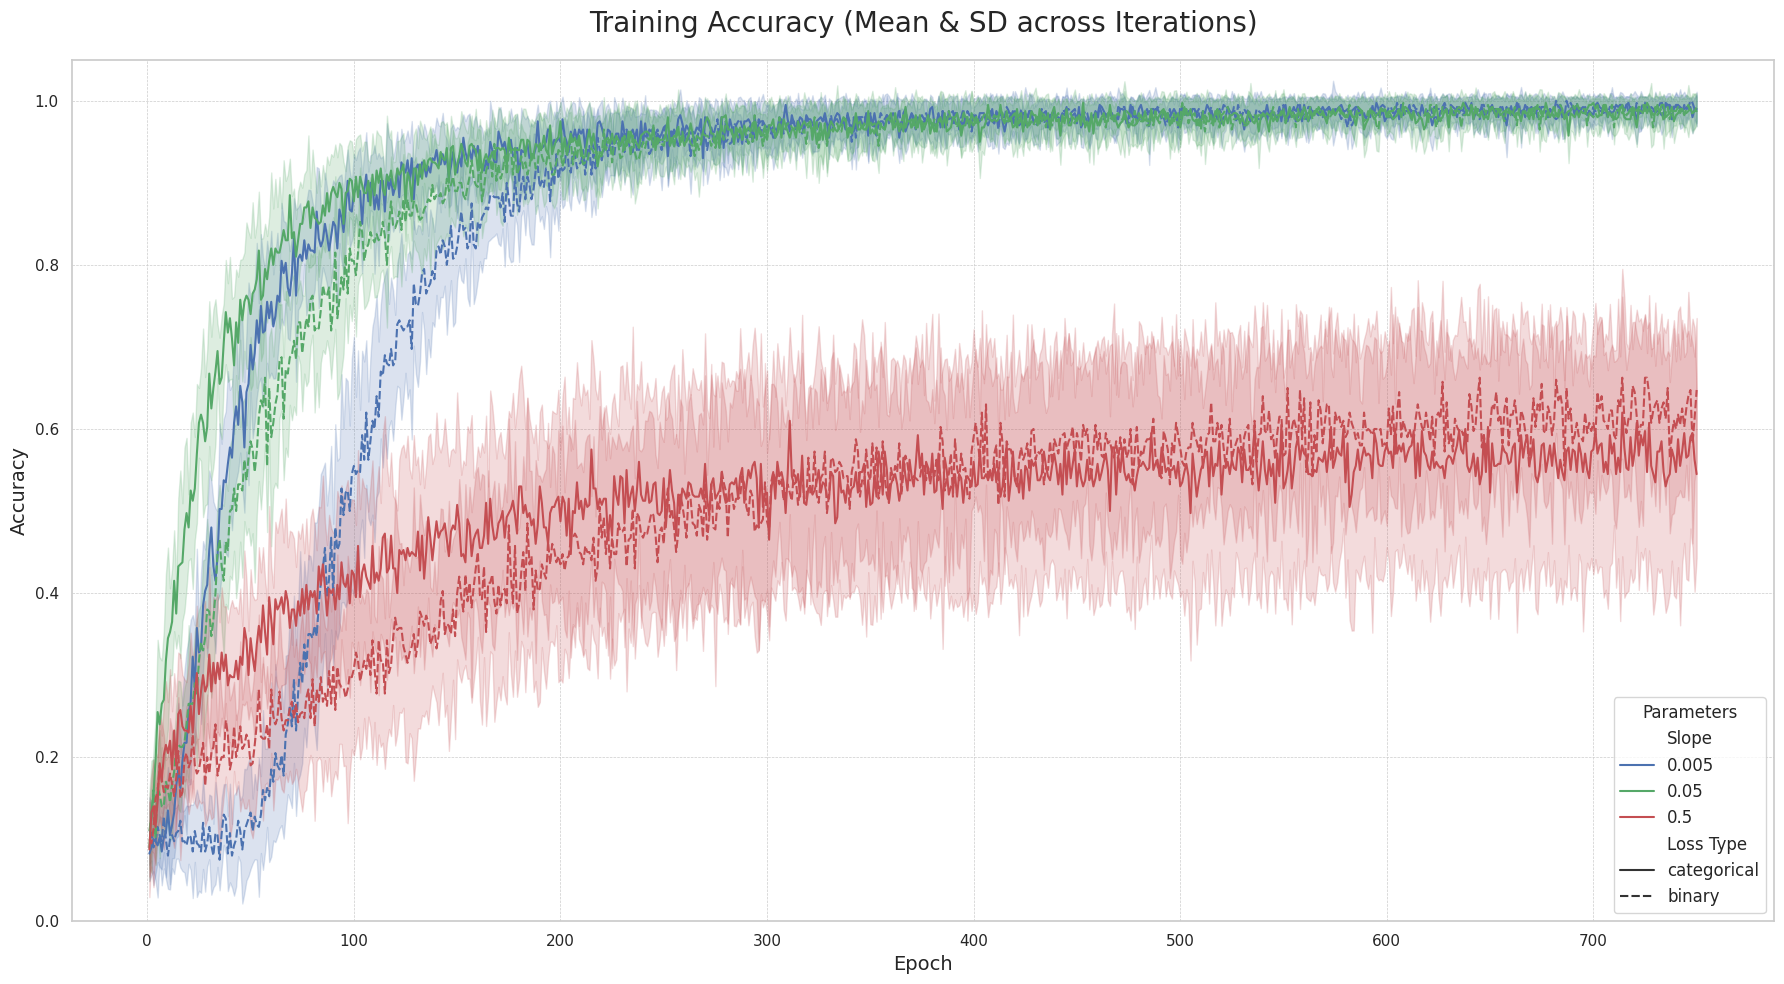


--- Analyzing models for: CATEGORICAL ---


Training Set Analysis (categorical): 100%|██████████| 3/3 [00:02<00:00,  1.10it/s]



--- Analyzing models for: BINARY ---


Training Set Analysis (binary): 100%|██████████| 3/3 [00:05<00:00,  1.74s/it]


--- Plotting 2/4: Single Image Case Study ---


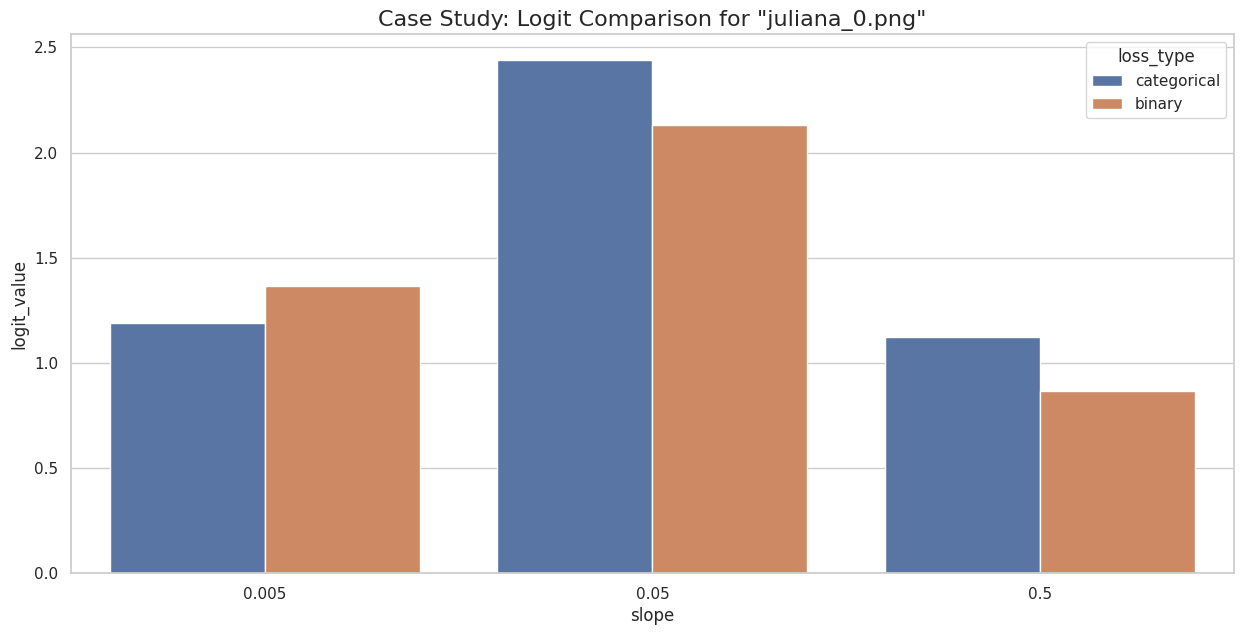

--- Plotting 3/4: Logit Distribution on Training Set ---


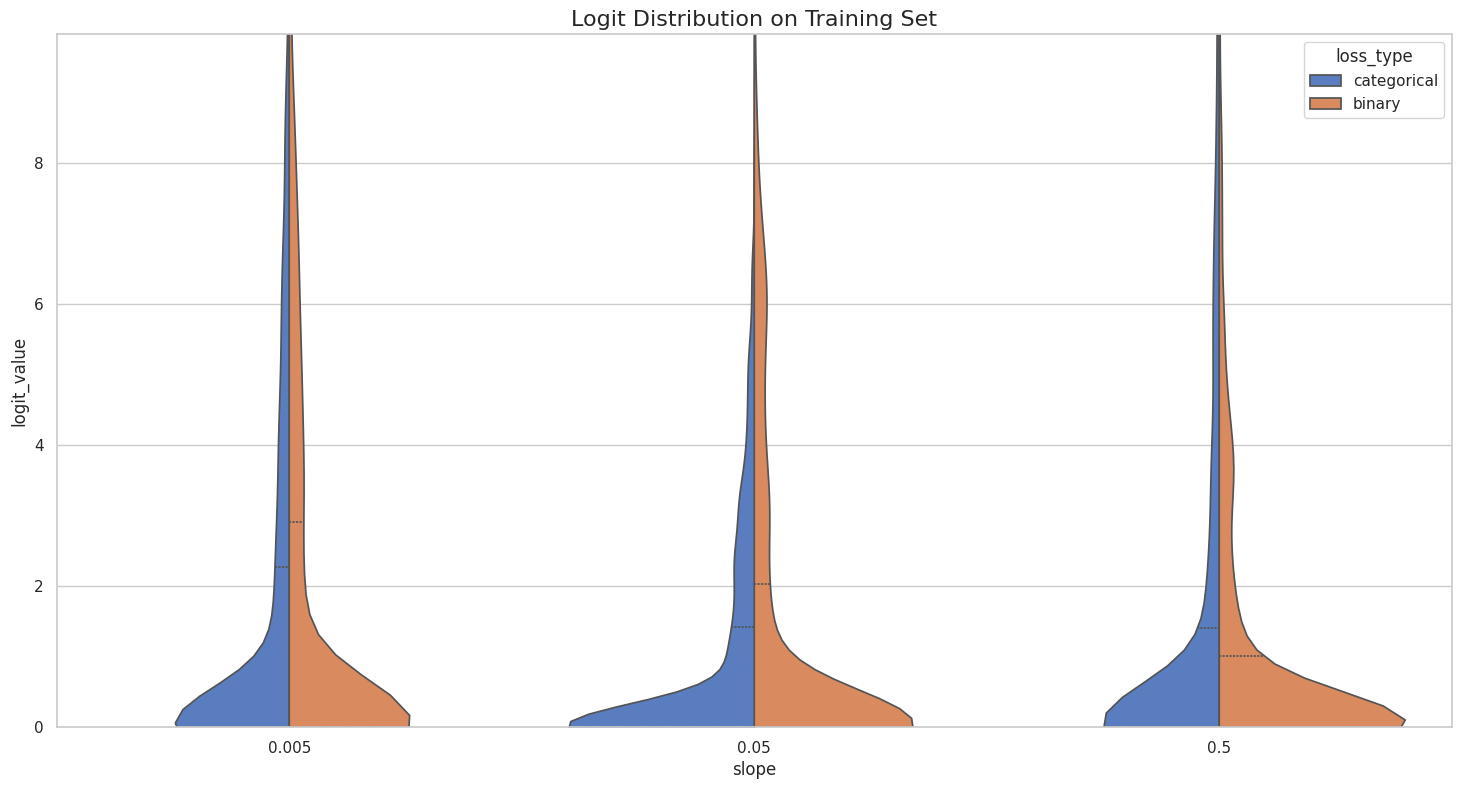

--- Plotting 4/4: Prediction Confidence on Training Set ---


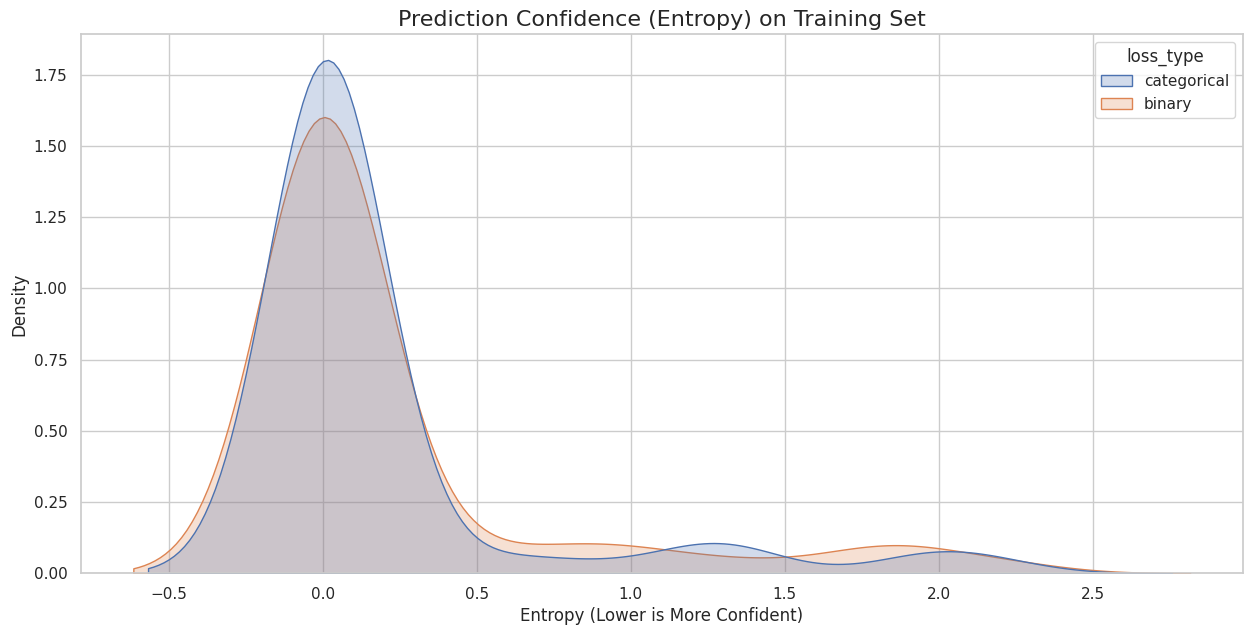


🎉 --- Analysis and Visualization complete! --- 🎉


✅✅✅ Entire pipeline completed successfully! ✅✅✅


In [5]:
BASE_RESIZE_TARGET = (128, 128)
FINAL_MODEL_INPUT_SHAPE = (130, 130, 3)
BASE_ANALYSIS_DIR = '../res/EIB_bc_750/'
os.makedirs(BASE_ANALYSIS_DIR, exist_ok=True)

training_params = {
    'positive_slope_list': [0.005, 0.05, 0.5], 
    'negative_slope_list': [0],
    'noise_level': 0, 
    'threshold_list': [0], 
    'epochs': 750,
    'num_iterations': 10, 
    'data_folder': '../data/training_data',
    'base_target_size': BASE_RESIZE_TARGET, 'model_input_shape': FINAL_MODEL_INPUT_SHAPE,
    'output_paths': {
        'categorical': os.path.join(BASE_ANALYSIS_DIR, 'c/'),
        'binary': os.path.join(BASE_ANALYSIS_DIR, 'b/')
    }
}

all_training_history = {}
for loss_type in ['categorical', 'binary']:
    history = run_training_pipeline(loss_type, params=training_params)
    all_training_history[loss_type] = history

analysis_params = {
    'base_analysis_dir': BASE_ANALYSIS_DIR,
    'output_paths': training_params['output_paths'],
    'positive_slope_list': training_params['positive_slope_list'],
    'analysis_iteration': 0,
    'single_image_path': os.path.join(training_params['data_folder'], 'juliana/juliana_0.png'),
    'juliana_index': 0,
    'data_folder': training_params['data_folder'],
    'base_target_size': BASE_RESIZE_TARGET
}

analyze_and_plot_results(all_training_history, analysis_params)

print("\n\n✅✅✅ Entire pipeline completed successfully! ✅✅✅")
